# Webinar — Regresión con Machine Learning
**TripleTen · Comparando modelos de regresión**

---
## Antes de arrancar

> *Una empresa inmobiliaria entrena un modelo para predecir el precio de casas. En pruebas: R² de 0.95. Lo despliegan. En producción el modelo predice $80,000 para una mansión de $500,000.*

**¿Qué crees que salió mal? Escribe en el chat.**

---

## Agenda

| # | Bloque |
|---|--------|
| 1 | Dataset y exploración |
| 2 | Métricas de regresión: RMSE, MAE, R² |
| 3 | Pipeline + Cross Validation |
| 4 | Comparar 3 modelos |
| 5 | GridSearch |
| 6 | Feature Importances |
| 7 | Modelo final |

**Al terminar vas a poder:**
- Entender cuándo usar RMSE vs MAE vs R²
- Detectar data leakage antes de entrenar
- Construir un pipeline completo de preprocesamiento + modelo
- Comparar LinearRegression, DecisionTree y RandomForest visualmente
- Identificar qué features impulsan el precio de una propiedad

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# Los 3 modelos que vamos a comparar
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

from sklearn.model_selection import cross_val_score, GridSearchCV, train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.datasets import fetch_california_housing

np.random.seed(42)
print('✅ Librerías cargadas')

✅ Librerías cargadas


---
# PARTE 1 — Dataset y exploración

Usamos **California Housing** — dataset clásico incluido en scikit-learn.  
El objetivo es predecir el **precio mediano de casas** (en cientos de miles de dólares) a partir de características del vecindario.

| Feature | Descripción |
|---------|-------------|
| `MedInc` | Ingreso mediano del vecindario |
| `HouseAge` | Antigüedad mediana de las casas |
| `AveRooms` | Promedio de habitaciones por hogar |
| `AveBedrms` | Promedio de dormitorios por hogar |
| `Population` | Población del bloque |
| `AveOccup` | Promedio de ocupantes por hogar |
| `Latitude` | Latitud |
| `Longitude` | Longitud |
| `MedHouseVal` | **Target**: valor mediano de la casa |


In [2]:
# Cargar dataset
housing = fetch_california_housing(as_frame=True)
df = housing.frame

print(f'Shape: {df.shape}')
print(f'Nulos: {df.isnull().sum().sum()}')
print(f'Target (MedHouseVal): min={df.MedHouseVal.min():.2f}, max={df.MedHouseVal.max():.2f}, media={df.MedHouseVal.mean():.2f}')
df.head()

Shape: (20640, 9)
Nulos: 0
Target (MedHouseVal): min=0.15, max=5.00, media=2.07


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


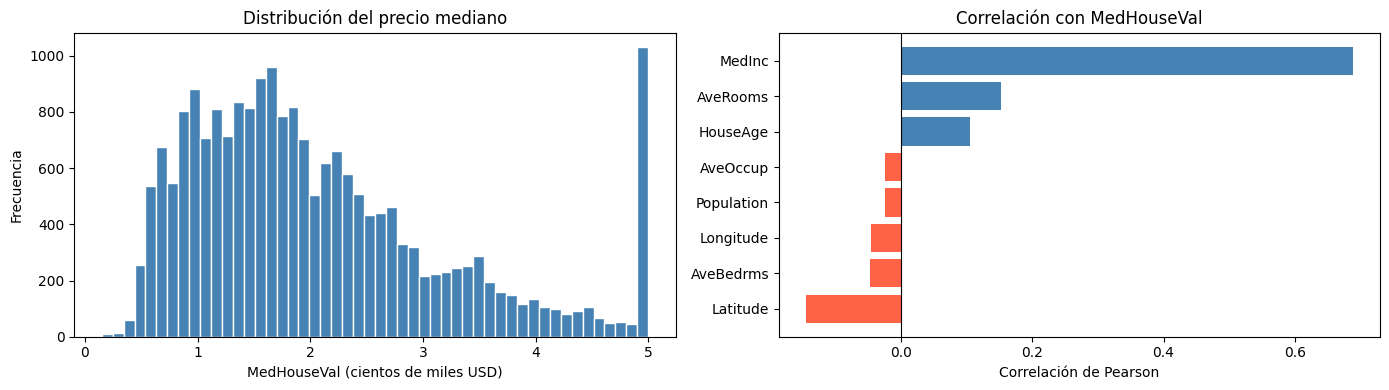

In [3]:
# Distribución del target y correlaciones
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Distribución del target
axes[0].hist(df['MedHouseVal'], bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('Distribución del precio mediano')
axes[0].set_xlabel('MedHouseVal (cientos de miles USD)')
axes[0].set_ylabel('Frecuencia')

# Correlación de features con el target
corrs = df.corr()['MedHouseVal'].drop('MedHouseVal').sort_values()
colors = ['tomato' if c < 0 else 'steelblue' for c in corrs]
axes[1].barh(corrs.index, corrs.values, color=colors)
axes[1].axvline(0, color='black', linewidth=0.8)
axes[1].set_title('Correlación con MedHouseVal')
axes[1].set_xlabel('Correlación de Pearson')

plt.tight_layout()
plt.show()

# Nota: MedInc tiene la correlación más alta (~0.69) — pista sobre feature importance

---
# PARTE 2 — Data leakage en regresión

En regresión el data leakage es más silencioso que en clasificación — el modelo sigue funcionando, pero con métricas irreales.

**Ejemplo típico en precios de casas:**
- `precio_por_m2` = `precio_final / metros_cuadrados` → usa el target para calcular la feature ❌
- `valuacion_fiscal_actualizada` → se calcula después de la venta ❌
- `historial_de_ventas_reciente` → no existe al momento de predecir ❌

**Regla de oro:** antes de meter una columna al modelo, preguntá —  
*¿Esta información estaría disponible en el momento real de la predicción?*

Vamos a simular el leakage para ver el efecto:

In [4]:
# Simulamos una columna con leakage: precio ruidoso derivado del target
df_leak = df.copy()
df_leak['precio_estimado_agencia'] = df['MedHouseVal'] * 0.95 + np.random.normal(0, 0.05, len(df))

# Modelo CON leakage
from sklearn.linear_model import LinearRegression

X_leak = df_leak.drop('MedHouseVal', axis=1)
y = df_leak['MedHouseVal']

X_tr_l, X_te_l, y_tr_l, y_te_l = train_test_split(X_leak, y, test_size=0.2, random_state=42)
m_leak = LinearRegression().fit(X_tr_l, y_tr_l)
r2_leak = r2_score(y_te_l, m_leak.predict(X_te_l))

# Modelo SIN leakage
X_clean = df.drop('MedHouseVal', axis=1)
X_tr_c, X_te_c, y_tr_c, y_te_c = train_test_split(X_clean, y, test_size=0.2, random_state=42)
m_clean = LinearRegression().fit(X_tr_c, y_tr_c)
r2_clean = r2_score(y_te_c, m_clean.predict(X_te_c))

print('=' * 45)
print(f'  R² CON leakage:   {r2_leak:.4f}  ⚠️  Trampa!')
print(f'  R² SIN leakage:   {r2_clean:.4f}  ✅  Real')
print('=' * 45)
print('\n💡 El modelo con leakage parece mucho mejor, pero en producción colapsaría.')

  R² CON leakage:   0.9979  ⚠️  Trampa!
  R² SIN leakage:   0.5758  ✅  Real

💡 El modelo con leakage parece mucho mejor, pero en producción colapsaría.


---
# PARTE 3 — Métricas de regresión

A diferencia de clasificación (accuracy, f1), en regresión medimos **qué tan lejos** está la predicción del valor real.

| Métrica | Fórmula | Interpretación | Sensible a outliers |
|---------|---------|----------------|---------------------|
| **MAE** | media(\|real - pred\|) | Error promedio en la misma unidad del target | No mucho |
| **RMSE** | √media((real - pred)²) | Penaliza más los errores grandes | Sí, bastante |
| **R²** | 1 - SS_res/SS_tot | % de varianza explicada. 1.0 = perfecto, 0 = trivial | No tanto |

**¿Cuándo usar cada una?**
- Si los errores grandes son muy costosos (medicina, finanzas) → **RMSE**
- Si todos los errores pesan igual → **MAE**
- Para comparar modelos en términos relativos → **R²**

In [5]:
# Función helper que usaremos en toda la clase
def evaluar_modelo(nombre, y_true, y_pred):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2   = r2_score(y_true, y_pred)
    print(f'{nombre:<25} | MAE: {mae:.4f} | RMSE: {rmse:.4f} | R²: {r2:.4f}')
    return {'modelo': nombre, 'MAE': mae, 'RMSE': rmse, 'R2': r2}

# Demo rápido con baseline
baseline_pred = np.full(len(y_te_c), y_tr_c.mean())  # siempre predice la media
evaluar_modelo('Baseline (media siempre)', y_te_c, baseline_pred)
print('\n💡 Este es el piso mínimo — cualquier modelo debe superar esto.')

Baseline (media siempre)  | MAE: 0.9061 | RMSE: 1.1449 | R²: -0.0002

💡 Este es el piso mínimo — cualquier modelo debe superar esto.


---
# PARTE 4 — Pipeline + Cross Validation

### ¿Por qué Pipeline?
1. Evita data leakage en el preprocesamiento (el scaler aprende solo del train)
2. Reproducible: un solo objeto para entrenar, evaluar y predecir
3. Compatible con GridSearchCV directamente

### ¿Por qué Cross Validation?
Un solo split train/test puede darte suerte (o mala suerte). CV te da **K evaluaciones independientes** y con eso una estimación del rendimiento real del modelo con su varianza.

In [6]:
# Preparar datos limpios (sin leakage)
X = df.drop('MedHouseVal', axis=1)
y = df['MedHouseVal']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f'Train: {X_train.shape} | Test: {X_test.shape}')

# Todas las features son numéricas en este dataset
features_num = X.columns.tolist()

# Preprocesador: imputer + scaler para numéricas
preprocessor = ColumnTransformer([
    ('num', Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ]), features_num)
])

print('✅ Preprocesador listo')

Train: (16512, 8) | Test: (4128, 8)
✅ Preprocesador listo


In [7]:
# Pipeline con LinearRegression como punto de partida
pipeline_lr = Pipeline([
    ('preprocessing', preprocessor),
    ('model', LinearRegression())
])

# Cross Validation con R² (5 folds)
cv_scores = cross_val_score(pipeline_lr, X_train, y_train, cv=5, scoring='r2')

print('LinearRegression — CV (5 folds):')
print(f'  R² por fold: {[round(s, 4) for s in cv_scores]}')
print(f'  Media: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}')
print('\n💡 La desviación estándar nos dice qué tan estable es el modelo entre distintos subconjuntos de datos.')

LinearRegression — CV (5 folds):
  R² por fold: [np.float64(0.6201), np.float64(0.613), np.float64(0.6134), np.float64(0.6107), np.float64(0.6002)]
  Media: 0.6115 ± 0.0065

💡 La desviación estándar nos dice qué tan estable es el modelo entre distintos subconjuntos de datos.


---
# PARTE 5 — Comparar los 3 modelos

Ahora sí el bloque central. Vamos a poner a competir:

| Modelo | Tipo | Strengths | Weaknesses |
|--------|------|-----------|------------|
| **LinearRegression** | Lineal | Rápido, interpretable, estable | No captura relaciones no lineales |
| **DecisionTreeRegressor** | No lineal | Captura no linealidades, interpretable | Overfitting fácil sin límite de profundidad |
| **RandomForestRegressor** | Ensemble | Robusto, reduce overfitting, muy preciso | Lento en predicción, menos interpretable |

**Hipótesis:** el precio de una casa NO es lineal respecto al ingreso — esperamos que los árboles superen a LinearRegression.

In [8]:
modelos = {
    'LinearRegression':      LinearRegression(),
    'DecisionTree':          DecisionTreeRegressor(random_state=42),
    'RandomForest':          RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
}

resultados_cv = {}

print(f'{"Modelo":<25} | {"R² Media":>10} | {"R² Std":>8} | {"RMSE Media":>12}')
print('-' * 65)

for nombre, modelo in modelos.items():
    pipe = Pipeline([
        ('preprocessing', preprocessor),
        ('model', modelo)
    ])
    
    r2_scores   = cross_val_score(pipe, X_train, y_train, cv=5, scoring='r2')
    rmse_scores = np.sqrt(-cross_val_score(pipe, X_train, y_train, cv=5,
                                            scoring='neg_mean_squared_error'))
    
    resultados_cv[nombre] = {
        'r2_scores': r2_scores,
        'rmse_scores': rmse_scores,
        'r2_mean': r2_scores.mean(),
        'r2_std': r2_scores.std(),
        'rmse_mean': rmse_scores.mean()
    }
    
    print(f'{nombre:<25} | {r2_scores.mean():>10.4f} | {r2_scores.std():>8.4f} | {rmse_scores.mean():>12.4f}')

Modelo                    |   R² Media |   R² Std |   RMSE Media
-----------------------------------------------------------------
LinearRegression          |     0.6115 |   0.0065 |       0.7205
DecisionTree              |     0.6069 |   0.0245 |       0.7243
RandomForest              |     0.8041 |   0.0055 |       0.5115


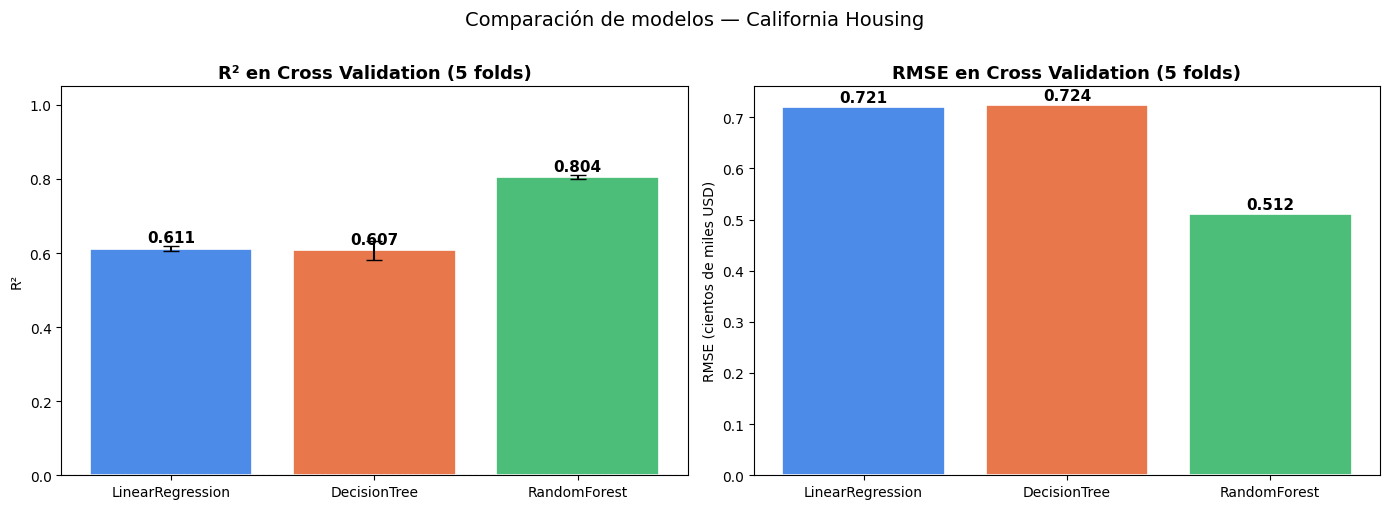


💡 Las barras de error muestran la estabilidad. Un modelo con R² alto pero std alta es menos confiable.


In [9]:
# Visualización comparativa con barras de error
nombres  = list(resultados_cv.keys())
r2_medias = [resultados_cv[n]['r2_mean']  for n in nombres]
r2_stds   = [resultados_cv[n]['r2_std']   for n in nombres]
rmse_medias = [resultados_cv[n]['rmse_mean'] for n in nombres]

colores = ['#4C8BE8', '#E8774C', '#4CBE7A']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# R² con barras de error (±1 std)
bars = axes[0].bar(nombres, r2_medias, color=colores, edgecolor='white', linewidth=1.2)
axes[0].errorbar(nombres, r2_medias, yerr=r2_stds, fmt='none',
                 color='black', capsize=6, linewidth=1.5)
axes[0].set_title('R² en Cross Validation (5 folds)', fontsize=13, fontweight='bold')
axes[0].set_ylabel('R²')
axes[0].set_ylim(0, 1.05)
axes[0].axhline(0, color='gray', linestyle='--', linewidth=0.8)
for bar, val in zip(bars, r2_medias):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                 f'{val:.3f}', ha='center', va='bottom', fontweight='bold', fontsize=11)

# RMSE
bars2 = axes[1].bar(nombres, rmse_medias, color=colores, edgecolor='white', linewidth=1.2)
axes[1].set_title('RMSE en Cross Validation (5 folds)', fontsize=13, fontweight='bold')
axes[1].set_ylabel('RMSE (cientos de miles USD)')
for bar, val in zip(bars2, rmse_medias):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
                 f'{val:.3f}', ha='center', va='bottom', fontweight='bold', fontsize=11)

plt.suptitle('Comparación de modelos — California Housing', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

print('\n💡 Las barras de error muestran la estabilidad. Un modelo con R² alto pero std alta es menos confiable.')

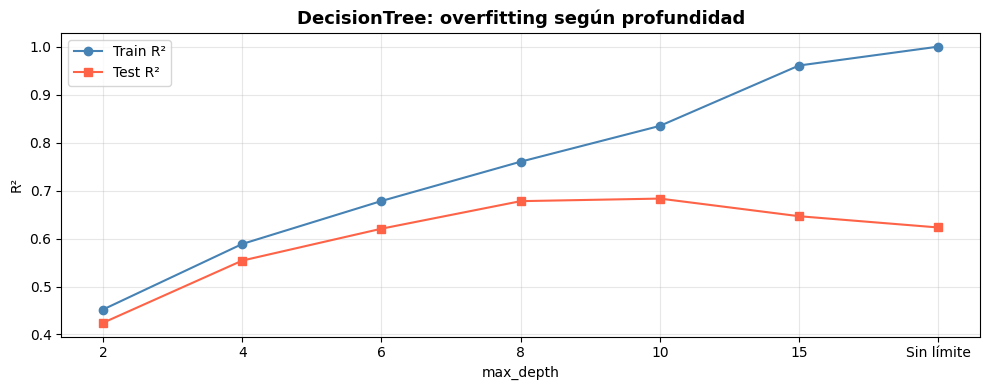

💡 Cuando Train R² ≈ 1.0 pero Test R² es bajo → overfitting clásico.
   El árbol memorizó el train, pero no generaliza.


In [10]:
# Demo de overfitting: DecisionTree sin límite vs con límite
profundidades = [2, 4, 6, 8, 10, 15, None]
r2_train_vals, r2_test_vals = [], []

for prof in profundidades:
    pipe = Pipeline([
        ('preprocessing', preprocessor),
        ('model', DecisionTreeRegressor(max_depth=prof, random_state=42))
    ])
    pipe.fit(X_train, y_train)
    r2_train_vals.append(r2_score(y_train, pipe.predict(X_train)))
    r2_test_vals.append(r2_score(y_test,  pipe.predict(X_test)))

etiquetas = [str(p) if p else 'Sin límite' for p in profundidades]

plt.figure(figsize=(10, 4))
plt.plot(etiquetas, r2_train_vals, 'o-', label='Train R²', color='steelblue')
plt.plot(etiquetas, r2_test_vals,  's-', label='Test R²',  color='tomato')
plt.title('DecisionTree: overfitting según profundidad', fontsize=13, fontweight='bold')
plt.xlabel('max_depth')
plt.ylabel('R²')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print('💡 Cuando Train R² ≈ 1.0 pero Test R² es bajo → overfitting clásico.')
print('   El árbol memorizó el train, pero no generaliza.')

---
# PARTE 6 — GridSearch

RandomForest ganó, pero estamos usando hiperparámetros por defecto.  
GridSearch busca sistemáticamente la mejor combinación.

**Hiperparámetros clave de RandomForest:**
- `n_estimators` — cantidad de árboles. Más árboles = más estable pero más lento
- `max_depth` — profundidad de cada árbol. Controla el overfitting
- `min_samples_split` — mínimo de muestras para hacer un split

In [11]:
# Pipeline para GridSearch
pipeline_rf = Pipeline([
    ('preprocessing', preprocessor),
    ('model', RandomForestRegressor(random_state=42, n_jobs=-1))
])

# Grid de hiperparámetros (prefijo 'model__' para referencias dentro del pipeline)
param_grid = {
    'model__n_estimators':    [100, 200],
    'model__max_depth':       [10, 20, None],
    'model__min_samples_split': [2, 5]
}

grid_search = GridSearchCV(
    pipeline_rf,
    param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

print('\n✅ GridSearch terminado')
print(f'Mejores parámetros: {grid_search.best_params_}')
print(f'Mejor R² en CV:     {grid_search.best_score_:.4f}')

Fitting 5 folds for each of 12 candidates, totalling 60 fits

✅ GridSearch terminado
Mejores parámetros: {'model__max_depth': 20, 'model__min_samples_split': 2, 'model__n_estimators': 200}
Mejor R² en CV:     0.8051


In [12]:
# Ver todos los resultados del grid ordenados
cv_results = pd.DataFrame(grid_search.cv_results_)
cols = [c for c in cv_results.columns if 'param_' in c] + ['mean_test_score', 'std_test_score', 'rank_test_score']
cv_results[cols].sort_values('rank_test_score').head(8)

,param_model__max_depth,param_model__min_samples_split,param_model__n_estimators,mean_test_score,std_test_score,rank_test_score
5,20,2,200,0.805062,0.005295,1
9,None,2,200,0.804819,0.005312,2
7,20,5,200,0.804674,0.005037,3
11,None,5,200,0.804648,0.005019,4
4,20,2,100,0.804625,0.005306,5
6,20,5,100,0.804292,0.005221,6
10,None,5,100,0.804215,0.005038,7
8,None,2,100,0.804118,0.005483,8


---
# PARTE 7 — Feature Importances

¿Qué le importa al modelo para predecir el precio?

**Recordatorio de cómo funciona en RandomForest:**  
Cada vez que un árbol hace un split usando una feature, mide cuánto redujo el MSE esa división.  
La importancia = suma acumulada de esas reducciones, promediada entre todos los árboles.  
Las importancias suman 1.0.

**Limitación:** tiene sesgo hacia features con muchos valores únicos (variables continuas).  
Por eso también veremos **Permutation Importance** como alternativa más robusta.

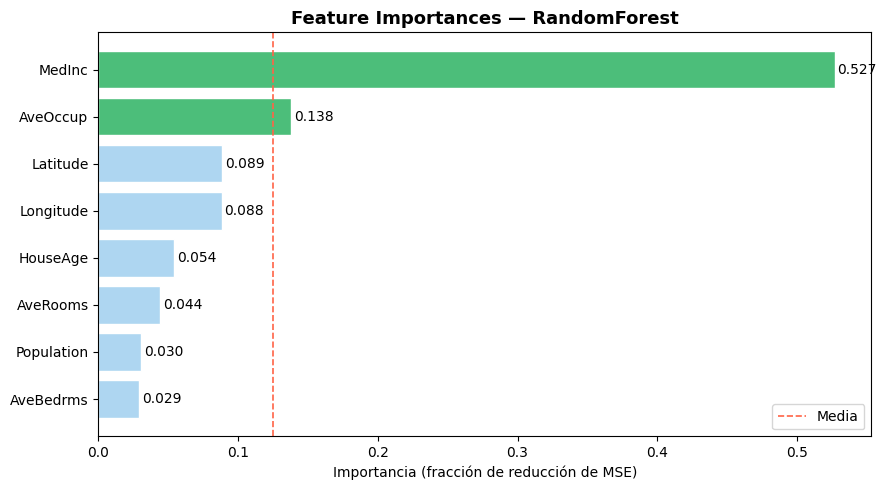


💡 Features por encima de la media (verde) son las más valiosas para el modelo.
   Top feature: MedInc (0.527)
   Coincide con la correlación más alta que vimos en la exploración? ✅


In [13]:
best_model = grid_search.best_estimator_

# Extraer importancias del RandomForest dentro del pipeline
rf_model = best_model.named_steps['model']
feature_names = features_num  # en este dataset todas son numéricas

importancias = pd.Series(
    rf_model.feature_importances_,
    index=feature_names
).sort_values(ascending=True)

# Plot
fig, ax = plt.subplots(figsize=(9, 5))
colors_imp = ['#4CBE7A' if v > importancias.mean() else '#AED6F1' for v in importancias]
bars = ax.barh(importancias.index, importancias.values, color=colors_imp, edgecolor='white')
ax.axvline(importancias.mean(), color='tomato', linestyle='--', linewidth=1.2, label='Media')
ax.set_title('Feature Importances — RandomForest', fontsize=13, fontweight='bold')
ax.set_xlabel('Importancia (fracción de reducción de MSE)')
ax.legend()

for bar, val in zip(bars, importancias.values):
    ax.text(val + 0.002, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=10)

plt.tight_layout()
plt.show()

print('\n💡 Features por encima de la media (verde) son las más valiosas para el modelo.')
print(f'   Top feature: {importancias.idxmax()} ({importancias.max():.3f})')
print(f'   Coincide con la correlación más alta que vimos en la exploración? ✅')

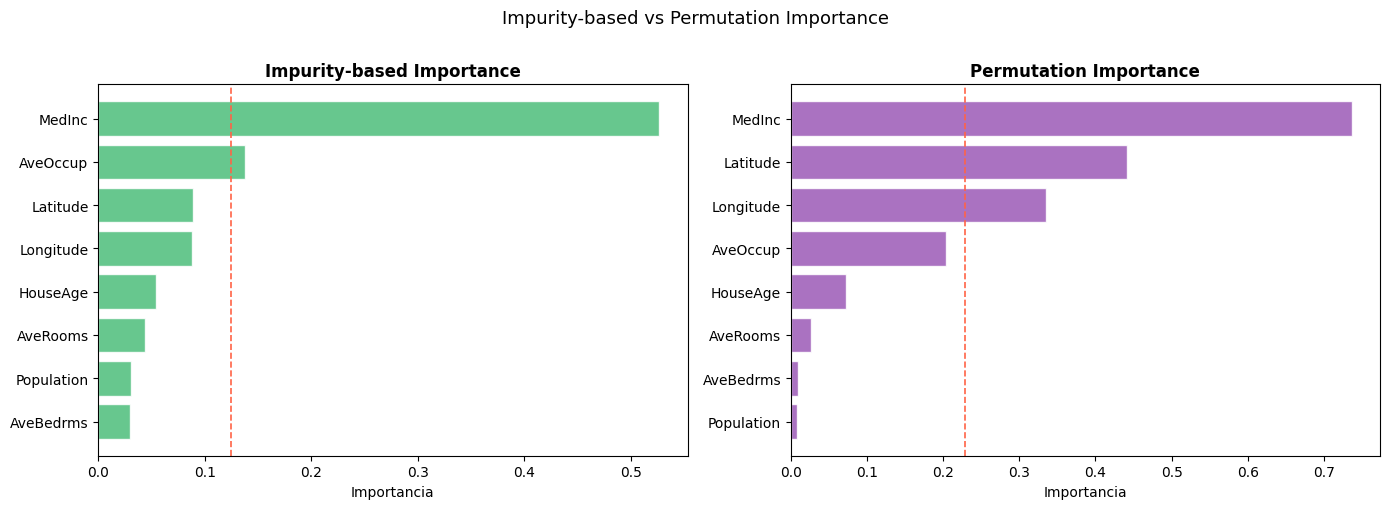

💡 Si el ranking coincide entre ambos métodos → más confianza en la importancia.
   Si difieren mucho → posible sesgo de cardinalidad en impurity-based.


In [14]:
# Permutation Importance — más robusta, no tiene sesgo de cardinalidad
from sklearn.inspection import permutation_importance

perm_imp = permutation_importance(
    best_model, X_test, y_test,
    n_repeats=10, random_state=42, n_jobs=-1
)

perm_series = pd.Series(
    perm_imp.importances_mean,
    index=feature_names
).sort_values(ascending=True)

# Comparación lado a lado
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, data, titulo, color in zip(
    axes,
    [importancias, perm_series],
    ['Impurity-based Importance', 'Permutation Importance'],
    ['#4CBE7A', '#9B59B6']
):
    ax.barh(data.index, data.values, color=color, alpha=0.85, edgecolor='white')
    ax.axvline(data.mean(), color='tomato', linestyle='--', linewidth=1.2)
    ax.set_title(titulo, fontsize=12, fontweight='bold')
    ax.set_xlabel('Importancia')

plt.suptitle('Impurity-based vs Permutation Importance', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

print('💡 Si el ranking coincide entre ambos métodos → más confianza en la importancia.')
print('   Si difieren mucho → posible sesgo de cardinalidad en impurity-based.')

---
# PARTE 8 — Modelo Final

Con los mejores hiperparámetros encontrados por GridSearch, entrenamos el modelo final  
sobre **todo el dataset de entrenamiento** y lo evaluamos sobre el test set que nunca tocamos.

In [15]:
# Evaluación final sobre test set
y_pred_final = best_model.predict(X_test)

mae_final  = mean_absolute_error(y_test, y_pred_final)
rmse_final = np.sqrt(mean_squared_error(y_test, y_pred_final))
r2_final   = r2_score(y_test, y_pred_final)

print('=' * 50)
print('  EVALUACIÓN FINAL — Test Set')
print('=' * 50)
print(f'  MAE:  {mae_final:.4f}  (~${mae_final*100_000:,.0f} USD de error promedio)')
print(f'  RMSE: {rmse_final:.4f}  (~${rmse_final*100_000:,.0f} USD)')
print(f'  R²:   {r2_final:.4f}  (explica el {r2_final*100:.1f}% de la varianza del precio)')
print('=' * 50)

  EVALUACIÓN FINAL — Test Set
  MAE:  0.3271  (~$32,712 USD de error promedio)
  RMSE: 0.5045  (~$50,448 USD)
  R²:   0.8058  (explica el 80.6% de la varianza del precio)


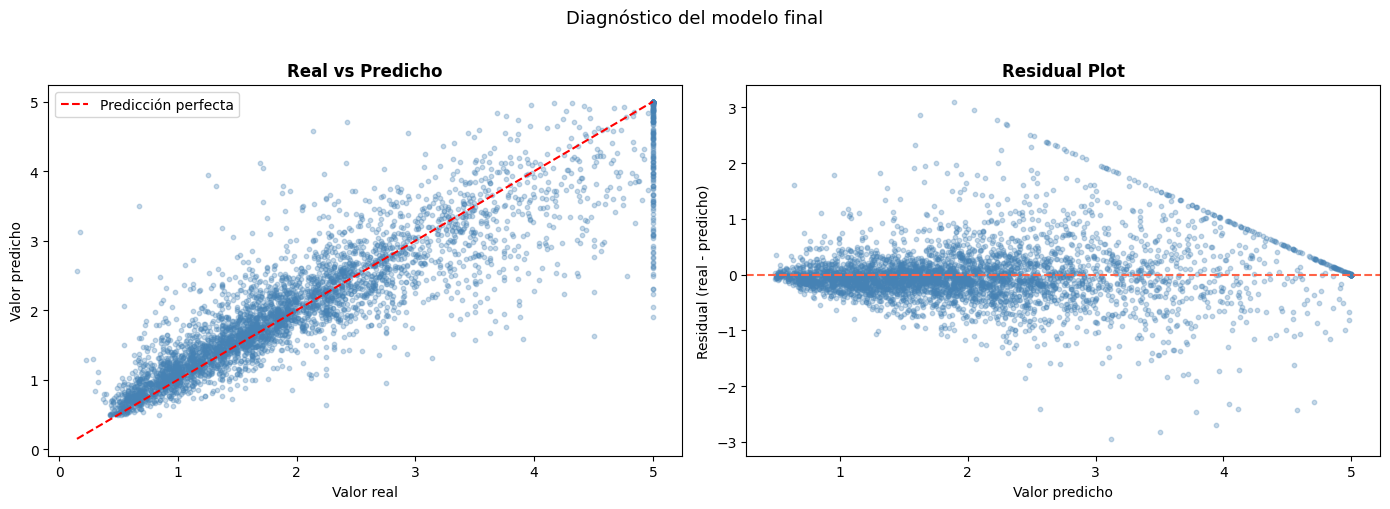

💡 Un buen modelo tiene residuales centrados en 0, sin patrones visibles.
   Si ves una "V" o una curva → el modelo tiene sesgo sistemático.
   Si ves que los residuales crecen con el valor predicho → heteroscedasticidad.


In [16]:
# Residual plot — detecta sesgos sistemáticos del modelo
residuales = y_test.values - y_pred_final

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Pred vs Real
axes[0].scatter(y_test, y_pred_final, alpha=0.3, s=10, color='steelblue')
lims = [min(y_test.min(), y_pred_final.min()), max(y_test.max(), y_pred_final.max())]
axes[0].plot(lims, lims, 'r--', linewidth=1.5, label='Predicción perfecta')
axes[0].set_xlabel('Valor real')
axes[0].set_ylabel('Valor predicho')
axes[0].set_title('Real vs Predicho', fontsize=12, fontweight='bold')
axes[0].legend()

# Residuales vs Predicho
axes[1].scatter(y_pred_final, residuales, alpha=0.3, s=10, color='steelblue')
axes[1].axhline(0, color='tomato', linestyle='--', linewidth=1.5)
axes[1].set_xlabel('Valor predicho')
axes[1].set_ylabel('Residual (real - predicho)')
axes[1].set_title('Residual Plot', fontsize=12, fontweight='bold')

plt.suptitle('Diagnóstico del modelo final', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

print('💡 Un buen modelo tiene residuales centrados en 0, sin patrones visibles.')
print('   Si ves una "V" o una curva → el modelo tiene sesgo sistemático.')
print('   Si ves que los residuales crecen con el valor predicho → heteroscedasticidad.')

In [17]:
# Tabla comparativa final de los 3 modelos sobre el test set
print(f'{"Modelo":<25} | {"MAE":>8} | {"RMSE":>8} | {"R²":>8}')
print('-' * 60)

resultados_finales = []
for nombre, modelo in modelos.items():
    pipe = Pipeline([
        ('preprocessing', preprocessor),
        ('model', modelo)
    ])
    pipe.fit(X_train, y_train)
    pred = pipe.predict(X_test)
    res = evaluar_modelo(nombre, y_test, pred)
    resultados_finales.append(res)

# Agregar el modelo optimizado con GridSearch
res_gs = evaluar_modelo('RF + GridSearch ⭐', y_test, y_pred_final)
resultados_finales.append(res_gs)

Modelo                    |      MAE |     RMSE |       R²
------------------------------------------------------------
LinearRegression          | MAE: 0.5332 | RMSE: 0.7456 | R²: 0.5758
DecisionTree              | MAE: 0.4539 | RMSE: 0.7028 | R²: 0.6230
RandomForest              | MAE: 0.3274 | RMSE: 0.5051 | R²: 0.8053
RF + GridSearch ⭐         | MAE: 0.3271 | RMSE: 0.5045 | R²: 0.8058


---
# Resumen

| Paso | Qué hace | Para qué sirve |
|------|----------|----------------|
| **Data leakage** | Detectar features calculadas con el target | Evitar modelos que hacen trampa |
| **Métricas** | MAE, RMSE, R² | Medir el error en unidades reales |
| **Pipeline** | Encadenar preprocesamiento + modelo | Reproducible y seguro en producción |
| **Cross Validation** | Evaluar con K folds + barras de error | Saber si el modelo es estable |
| **Comparación** | LinearReg vs DecisionTree vs RandomForest | Elegir el enfoque correcto para el problema |
| **GridSearch** | Buscar mejores hiperparámetros | Afinar sin perder generalización |
| **Feature Importances** | Qué columnas aportan más | Explicabilidad + detección de ruido |
| **Residual Plot** | Diagnosticar el modelo final | Detectar sesgos sistemáticos |

---
### Volvamos al caso del inicio

> El modelo pasó de R² 0.95 en pruebas a predecir $80,000 para una mansión de $500,000.

La columna `precio_estimado_agencia` era una transformación ruidosa del target mismo — el modelo aprendió a usarla como atajo. En producción esa columna no existe, y el modelo colapsa.

**Regla:** antes de meter una columna al modelo, preguntá —  
*¿Esta información estaría disponible en el momento real de la predicción?*